In [40]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC, SVR

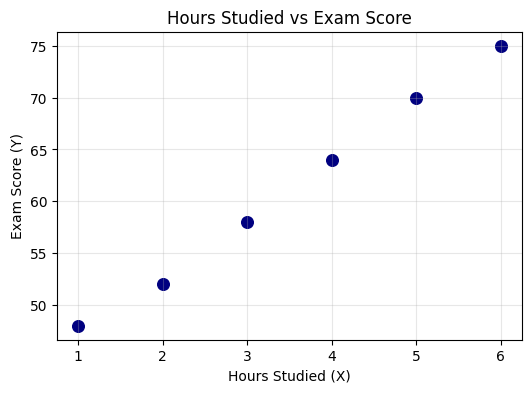

In [41]:
# Task 1 – Dataset and scatter plot
X = np.array([1, 2, 3, 4, 5, 6])          # Hours studied (feature)
y = np.array([48, 52, 58, 64, 70, 75])    # Exam score (target)

plt.figure(figsize=(6, 4))
plt.scatter(X, y, color='navy', s=70)
plt.xlabel('Hours Studied (X)')
plt.ylabel('Exam Score (Y)')
plt.title('Hours Studied vs Exam Score')
plt.grid(alpha=0.3)
plt.show()

In [42]:
# Task 2 – Prediction function (no sklearn)
def predict(X, beta0, beta1):
    return beta0 + beta1 * X

beta0, beta1 = 0, 0                        # initialise both to 0
y_hat = predict(X, beta0, beta1)
print("Initial predictions:", y_hat)
# b0 = intercept (score at 0 hours), b1 = slope (score gain per hour)

Initial predictions: [0 0 0 0 0 0]


In [43]:
# Task 3 – Residuals and MSE from scratch
def mse(y, y_hat):
    return np.mean((y - y_hat) ** 2)       # average squared error

residuals = y - y_hat
for i in range(len(y)):
    print(f"Obs {i+1}: actual={y[i]}, pred={y_hat[i]:.2f}, residual={residuals[i]:.2f}")

print("MSE =", mse(y, y_hat))
# Squaring removes sign and penalises large errors more

Obs 1: actual=48, pred=0.00, residual=48.00
Obs 2: actual=52, pred=0.00, residual=52.00
Obs 3: actual=58, pred=0.00, residual=58.00
Obs 4: actual=64, pred=0.00, residual=64.00
Obs 5: actual=70, pred=0.00, residual=70.00
Obs 6: actual=75, pred=0.00, residual=75.00
MSE = 3832.1666666666665


In [44]:
# Task 4 – Gradient descent training
learning_rate = 0.01
iterations = 1000
beta0, beta1 = 0, 0
loss_history = []
n = len(X)

for i in range(iterations):
    y_hat = predict(X, beta0, beta1)

    dbeta0 = (2 / n) * np.sum(y_hat - y)
    dbeta1 = (2 / n) * np.sum((y_hat - y) * X)

    beta0 -= learning_rate * dbeta0                   # update b0
    beta1 -= learning_rate * dbeta1                   # update b1

    loss_history.append(mse(y, predict(X, beta0, beta1)))   # store MSE

print(f"Final beta0 = {beta0:.4f}")
print(f"Final beta1 = {beta1:.4f}")
print(f"Final MSE   = {loss_history[-1]:.4f}")

Final beta0 = 40.6779
Final beta1 = 5.8024
Final MSE   = 0.4580


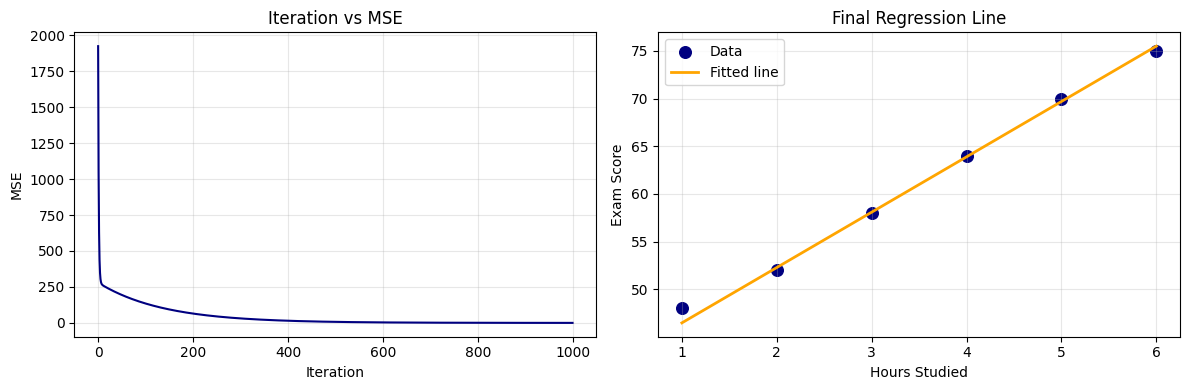

In [45]:
# Task 4 – Convergence curve + final regression line
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(loss_history, color='navy')
ax[0].set_xlabel('Iteration'); ax[0].set_ylabel('MSE')
ax[0].set_title('Iteration vs MSE'); ax[0].grid(alpha=0.3)

ax[1].scatter(X, y, color='navy', s=70, label='Data')
ax[1].plot(X, predict(X, beta0, beta1), color='orange', lw=2, label='Fitted line')
ax[1].set_xlabel('Hours Studied'); ax[1].set_ylabel('Exam Score')
ax[1].set_title('Final Regression Line'); ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [46]:
# Task 5 – MAE, MSE, RMSE, R2 from scratch
y_hat = predict(X, beta0, beta1)

mae  = np.mean(np.abs(y - y_hat))                                   # mean abs error
mse_ = np.mean((y - y_hat) ** 2)                                    # mean squared error
rmse = np.sqrt(mse_)                                                # same units as y
r2   = 1 - np.sum((y - y_hat) ** 2) / np.sum((y - y.mean()) ** 2)   # 1 - SSE/SST

print(f"MAE  = {mae:.4f}")
print(f"MSE  = {mse_:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R2   = {r2:.4f}")
print("Prediction for 4.5 hours:", predict(4.5, beta0, beta1))
# MAE & RMSE are in score units; MSE penalises large errors most

MAE  = 0.4671
MSE  = 0.4580
RMSE = 0.6767
R2   = 0.9950
Prediction for 4.5 hours: 66.78863020527274


In [47]:
# Activity 6 – Verify with scikit-learn LinearRegression
lin = LinearRegression().fit(X.reshape(-1, 1), y)

print("sklearn intercept:", lin.intercept_)
print("sklearn coef     :", lin.coef_[0])
print("Prediction for 4.5 hours:", lin.predict([[4.5]])[0])
# Values should be very close to the from-scratch model

sklearn intercept: 41.666666666666664
sklearn coef     : 5.571428571428571
Prediction for 4.5 hours: 66.73809523809524


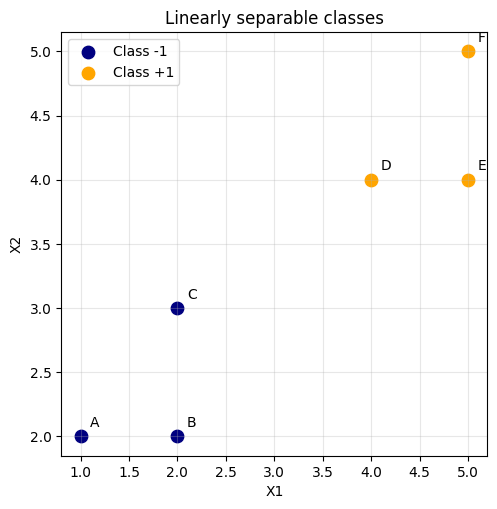

In [48]:
# Task 6 – Visualise the classification problem (Part B data)
Xb = np.array([[1, 2], [2, 2], [2, 3], [4, 4], [5, 4], [5, 5]])   # features
yb = np.array([-1, -1, -1, 1, 1, 1])                              # labels
labels = list('ABCDEF')

plt.figure(figsize=(5.5, 5.5))
plt.scatter(Xb[yb == -1, 0], Xb[yb == -1, 1], color='navy',   s=80, label='Class -1')
plt.scatter(Xb[yb == 1, 0],  Xb[yb == 1, 1],  color='orange', s=80, label='Class +1')
for i, (x1, x2) in enumerate(Xb):
    plt.annotate(labels[i], (x1, x2), textcoords='offset points', xytext=(7, 7))
plt.xlabel('X1'); plt.ylabel('X2')
plt.title('Linearly separable classes'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [49]:
# Task 7 – Fit linear SVC and inspect the decision function
svc = SVC(kernel='linear', C=1.0).fit(Xb, yb)

w, b = svc.coef_[0], svc.intercept_[0]
print("w =", w, " b =", b)

scores = Xb @ w + b
print("hand f(x)   :", np.round(scores, 4))
print("svc.dec_fn  :", np.round(svc.decision_function(Xb), 4))
print("predictions :", svc.predict(Xb))
print("actual      :", yb)

w = [0.8 0.4]  b = -3.8000000000000003
hand f(x)   : [-2.2 -1.4 -1.   1.   1.8  2.2]
svc.dec_fn  : [-2.2 -1.4 -1.   1.   1.8  2.2]
predictions : [-1 -1 -1  1  1  1]
actual      : [-1 -1 -1  1  1  1]


Support indices : [2 3]
Support vectors :
 [[2. 3.]
 [4. 4.]]
Margin width 2/||w|| = 2.23606797749979


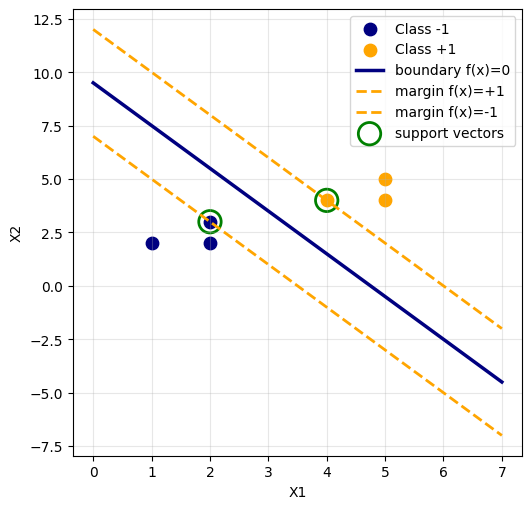

In [50]:
# Task 8 – Margin boundaries and support vectors
print("Support indices :", svc.support_)
print("Support vectors :\n", svc.support_vectors_)
print("Margin width 2/||w|| =", 2 / np.linalg.norm(w))

x1 = np.linspace(0, 7, 100)
line = lambda off: (off - b - w[0] * x1) / w[1]

plt.figure(figsize=(5.8, 5.8))
plt.scatter(Xb[yb == -1, 0], Xb[yb == -1, 1], color='navy',   s=80, label='Class -1')
plt.scatter(Xb[yb == 1, 0],  Xb[yb == 1, 1],  color='orange', s=80, label='Class +1')
plt.plot(x1, line(0),  color='navy',   lw=2.5, label='boundary f(x)=0')
plt.plot(x1, line(1),  color='orange', ls='--', lw=2, label='margin f(x)=+1')
plt.plot(x1, line(-1), color='orange', ls='--', lw=2, label='margin f(x)=-1')
plt.scatter(svc.support_vectors_[:, 0], svc.support_vectors_[:, 1],
            s=260, facecolors='none', edgecolors='green', lw=2, label='support vectors')
plt.xlabel('X1'); plt.ylabel('X2'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [51]:
# Task 9 – Hinge loss from the fitted model
scores = svc.decision_function(Xb)
hinge = np.maximum(0, 1 - yb * scores)

for i in range(len(yb)):
    print(f"{labels[i]}: y={yb[i]:+d}, f(x)={scores[i]:+.3f}, hinge={hinge[i]:.3f}")

print("\nZero-loss points :", [labels[i] for i in np.where(hinge == 0)[0]])
print("Support vectors  :", [labels[i] for i in svc.support_])
# Points outside the margin - 0 loss; on/inside margin - positive loss

A: y=-1, f(x)=-2.200, hinge=0.000
B: y=-1, f(x)=-1.400, hinge=0.000
C: y=-1, f(x)=-1.000, hinge=0.000
D: y=+1, f(x)=+1.000, hinge=0.000
E: y=+1, f(x)=+1.800, hinge=0.000
F: y=+1, f(x)=+2.200, hinge=0.000

Zero-loss points : ['A', 'B', 'C', 'D', 'E', 'F']
Support vectors  : ['C', 'D']


In [52]:
# Task 10 – Effect of C on the margin (numbers)
for C in [0.05, 0.1, 0.3, 1.0]:
    m = SVC(kernel='linear', C=C).fit(Xb, yb)
    wc, bc = m.coef_[0], m.intercept_[0]
    width = 2 / np.linalg.norm(wc)
    print(f"C={C:<5} margin width={width:.3f}  support vectors="
          f"{[labels[i] for i in m.support_]}")

C=0.05  margin width=4.986  support vectors=['A', 'B', 'C', 'D', 'E', 'F']
C=0.1   margin width=3.601  support vectors=['B', 'C', 'D', 'E']
C=0.3   margin width=2.981  support vectors=['C', 'D']
C=1.0   margin width=2.236  support vectors=['C', 'D']


w = 5.0  b = 44.0
hand  : [49. 54. 59. 64. 69. 74.]
svr   : [49. 54. 59. 64. 69. 74.]


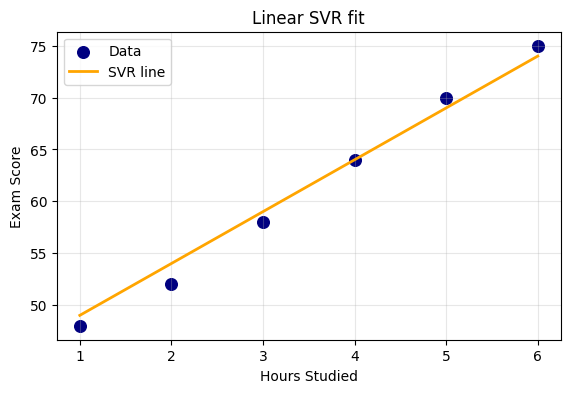

In [53]:
# Task 11 – Fit linear SVR on the Hours -> Score data
svr = SVR(kernel='linear', C=1.0, epsilon=1.0).fit(X.reshape(-1, 1), y)

w, b = svr.coef_[0][0], svr.intercept_[0]
print("w =", w, " b =", b)

preds_hand = w * X + b
print("hand  :", np.round(preds_hand, 4))
print("svr   :", np.round(svr.predict(X.reshape(-1, 1)), 4))

plt.figure(figsize=(6.5, 4))
plt.scatter(X, y, color='navy', s=70, label='Data')
plt.plot(X, preds_hand, color='orange', lw=2, label='SVR line')
plt.xlabel('Hours Studied'); plt.ylabel('Exam Score')
plt.title('Linear SVR fit'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

Support indices : [1 2 4 5] -> ['B', 'C', 'E', 'F']
Inside tube     : ['D']
On/outside tube : ['A', 'B', 'C', 'E', 'F']


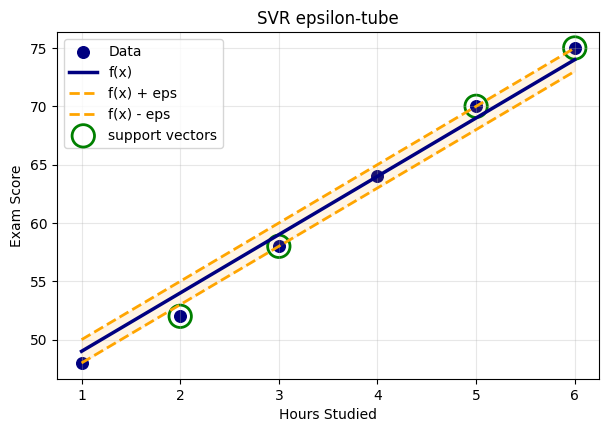

In [54]:
# Task 12 – Build and visualise the epsilon-tube
preds = svr.predict(X.reshape(-1, 1))
upper = preds + svr.epsilon
lower = preds - svr.epsilon
inside = np.abs(y - preds) < svr.epsilon                # zero-loss points

print("Support indices :", svr.support_, "->", [labels[i] for i in svr.support_])
print("Inside tube     :", [labels[i] for i in np.where(inside)[0]])
print("On/outside tube :", [labels[i] for i in np.where(~inside)[0]])

plt.figure(figsize=(7, 4.5))
plt.scatter(X, y, color='navy', s=70, label='Data')
plt.plot(X, preds, color='navy',   lw=2.5, label='f(x)')
plt.plot(X, upper, color='orange', ls='--', lw=2, label='f(x) + eps')
plt.plot(X, lower, color='orange', ls='--', lw=2, label='f(x) - eps')
plt.fill_between(X, lower, upper, color='orange', alpha=0.10)
plt.scatter(X[svr.support_], y[svr.support_], s=260,
            facecolors='none', edgecolors='green', lw=2, label='support vectors')
plt.xlabel('Hours Studied'); plt.ylabel('Exam Score')
plt.title('SVR epsilon-tube'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [55]:
# Task 13 – epsilon-insensitive loss
loss = np.maximum(0, np.abs(y - preds) - svr.epsilon)

df = pd.DataFrame({
    'Actual':    y,
    'Predicted': preds.round(3),
    'AbsError':  np.abs(y - preds).round(3),
    'Loss':      loss.round(3)
}, index=labels)
print(df)

print("\nZero-loss points:", [labels[i] for i in np.where(loss == 0)[0]])
print("Support vectors :", [labels[i] for i in svr.support_])
# Zero loss = strictly inside tube; support vectors sit on/outside the tube

   Actual  Predicted  AbsError  Loss
A      48       49.0       1.0   0.0
B      52       54.0       2.0   1.0
C      58       59.0       1.0   0.0
D      64       64.0       0.0   0.0
E      70       69.0       1.0   0.0
F      75       74.0       1.0   0.0

Zero-loss points: ['A', 'C', 'D', 'E', 'F']
Support vectors : ['B', 'C', 'E', 'F']


In [56]:
# Task 14 – Effect of epsilon on the tube (numbers)
for eps in [0.1, 0.5, 1.0, 3.0]:
    m = SVR(kernel='linear', C=1.0, epsilon=eps).fit(X.reshape(-1, 1), y)
    print(f"eps={eps:<4} w={m.coef_[0][0]:.3f} b={m.intercept_[0]:.3f} "
          f"support vectors={[labels[i] for i in m.support_]}")

eps=0.1  w=5.400 b=42.500 support vectors=['A', 'B', 'C', 'D', 'E', 'F']
eps=0.5  w=5.333 b=42.500 support vectors=['B', 'C', 'E', 'F']
eps=1.0  w=5.000 b=44.000 support vectors=['B', 'C', 'E', 'F']
eps=3.0  w=4.000 b=47.000 support vectors=['B', 'F']


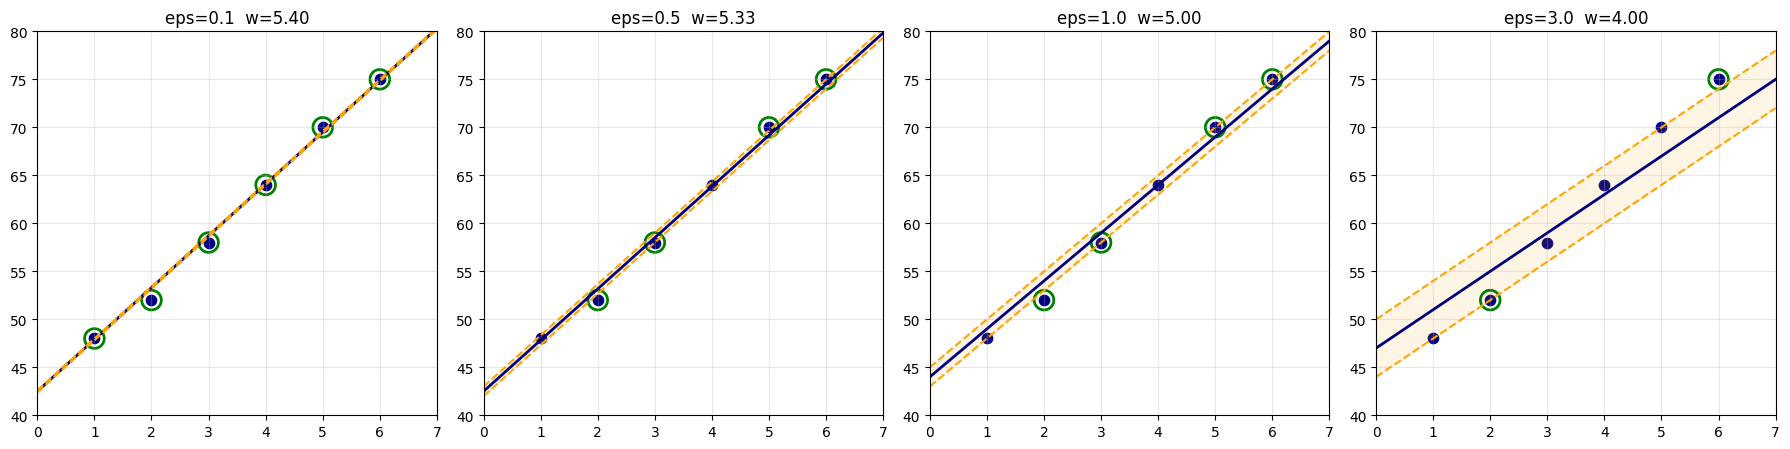

In [57]:
# Task 14 – Effect of epsilon on the tube (plots)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.6))
xs = np.linspace(0, 7, 100)

for ax, eps in zip(axes, [0.1, 0.5, 1.0, 3.0]):
    m = SVR(kernel='linear', C=1.0, epsilon=eps).fit(X.reshape(-1, 1), y)
    ww, bb = m.coef_[0][0], m.intercept_[0]

    ax.scatter(X, y, color='navy', s=55)
    ax.plot(xs, ww * xs + bb, color='navy', lw=2)                 # fitted line
    ax.plot(xs, ww * xs + bb + eps, color='orange', ls='--')      # upper tube
    ax.plot(xs, ww * xs + bb - eps, color='orange', ls='--')      # lower tube
    ax.fill_between(xs, ww * xs + bb - eps, ww * xs + bb + eps, color='orange', alpha=0.10)
    ax.scatter(X[m.support_], y[m.support_], s=200,
               facecolors='none', edgecolors='green', lw=2)
    ax.set_title(f"eps={eps}  w={ww:.2f}")
    ax.set_xlim(0, 7); ax.set_ylim(40, 80); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()
# Large eps - wide tube, fewer SVs, flatter line (less sensitive to outliers)

In [58]:
# Task 15 – Model comparison
comparison = pd.DataFrame({
    'Property': ['Target type', 'Main purpose', 'Output',
                 'Main loss/error concept', 'Margin / eps-tube', 'Role of support vectors'],
    'Linear Regression': ['', '', '', '', 'Not applicable', 'Not applicable'],
    'SVM':               ['', '', '', '', '', ''],
    'SVR':               ['', '', '', '', '', '']
})
print(comparison.to_string(index=False))

               Property Linear Regression SVM SVR
            Target type                          
           Main purpose                          
                 Output                          
Main loss/error concept                          
      Margin / eps-tube    Not applicable        
Role of support vectors    Not applicable        
